In [1]:
# importing the requried labires 
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
!pip install xlrd

ds = pd.read_excel("Concrete_Data.xls")

In [3]:
ds.head(3)

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535


In [4]:
ds.shape

(1030, 9)

In [5]:
ds.isnull().sum()

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64

In [6]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)  

In [7]:
ds.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [8]:
# not having any missing values

In [9]:
ds.columns

Index(['Cement (component 1)(kg in a m^3 mixture)',
       'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
       'Fly Ash (component 3)(kg in a m^3 mixture)',
       'Water  (component 4)(kg in a m^3 mixture)',
       'Superplasticizer (component 5)(kg in a m^3 mixture)',
       'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
       'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)',
       'Concrete compressive strength(MPa, megapascals) '],
      dtype='object')

In [10]:
# checking for duplicates values
ds.duplicated().sum()

np.int64(25)

In [11]:
ds = ds.drop_duplicates()

In [12]:
ds.duplicated().sum()

np.int64(0)

In [13]:
ds.columns = [*ds.columns[:-1], "Concrete compressive strength"]

In [14]:
ds.head(3)

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535


In [15]:
# seprating featuresand coloum 
X = ds.drop("Concrete compressive strength",axis=1)
y = ds["Concrete compressive strength"]

In [16]:
# spliting the valuesa
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
scaler = StandardScaler()

In [18]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
  import tensorflow as tf
  from tensorflow.keras.models import Sequential
  from tensorflow.keras.layers import Dense

In [20]:
model = Sequential(
    [
        Dense(64,activation='relu',input_shape=(X_train.shape[1],)),
        Dense(32,activation='relu'),
        Dense(1,)
    ]
)

C:\Users\abhia\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


model.summary()

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
import tensorflow as tf
opt = tf.keras.optimizers.Adam(learning_rate = 0.01)

In [23]:
model.compile(
    
        optimizer = opt,
        loss = "mse",
         metrics = ['mae']
    
)

In [24]:
import datetime
from tensorflow.keras.callbacks import TensorBoard

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

In [25]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
call_back = EarlyStopping( monitor='val_loss',  patience=15,  restore_best_weights=True,)

In [26]:
kk = model.fit(X_train,y_train,  validation_data=(X_test,y_test),epochs=50,
                 callbacks = [tensorboard_callback,call_back])

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 793.8079 - mae: 23.0543 - val_loss: 387.6212 - val_mae: 15.1655
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 223.8741 - mae: 11.8736 - val_loss: 200.6918 - val_mae: 11.4299
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 148.8552 - mae: 9.9093 - val_loss: 178.5501 - val_mae: 11.0346
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 138.2343 - mae: 9.5938 - val_loss: 162.4420 - val_mae: 10.4322
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 127.6536 - mae: 9.1870 - val_loss: 156.1456 - val_mae: 10.2008
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 128.1520 - mae: 9.1447 - val_loss: 147.9325 - val_mae: 9.9446
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 115.9294 - mae: 8.6942 - val_loss: 145.4935 - val_mae: 9.9061
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 116.4994 - mae: 8.6816 - val_loss: 136.7385 - val_mae: 9.4968
Epoch 9/50
26/26 ━━━━━━━━

In [27]:
# checking the prediction 
y_pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [28]:
print(y_pred[:10])

[[27.055609]
 [21.35439 ]
 [28.537252]
 [33.89274 ]
 [48.092476]
 [27.532515]
 [17.822475]
 [31.426405]
 [29.539078]
 [38.69388 ]]


In [29]:
y_pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [30]:
print(y_pred[:10])

[[27.055609]
 [21.35439 ]
 [28.537252]
 [33.89274 ]
 [48.092476]
 [27.532515]
 [17.822475]
 [31.426405]
 [29.539078]
 [38.69388 ]]


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 4.738273020082084
MSE: 42.17199000131541
RMSE: 6.493996458369485
R² Score: 0.858638922543969


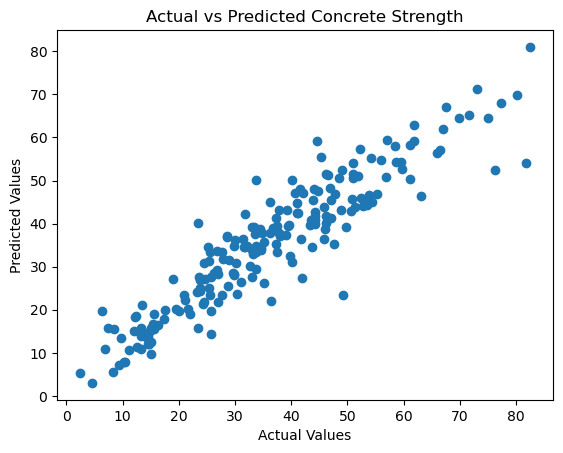

In [32]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Concrete Strength")
plt.show()

In [33]:
import numpy as np

# Take input from user
cement = float(input("Enter Cement: "))
slag = float(input("Enter Blast Furnace Slag: "))
fly_ash = float(input("Enter Fly Ash: "))
water = float(input("Enter Water: "))
superplasticizer = float(input("Enter Superplasticizer: "))
coarse_aggregate = float(input("Enter Coarse Aggregate: "))
fine_aggregate = float(input("Enter Fine Aggregate: "))
age = float(input("Enter Age: "))

# Create input array
user_input = np.array([[
    cement,
    slag,
    fly_ash,
    water,
    superplasticizer,
    coarse_aggregate,
    fine_aggregate,
    age
]])

# Scale the input
user_input_scaled = scaler.transform(user_input)

# Predict
prediction = model.predict(user_input_scaled)

print("Predicted Concrete Strength:", prediction[0][0], "MPa")

Enter Cement:  540
Enter Blast Furnace Slag:  0
Enter Fly Ash:  0
Enter Water:  162
Enter Superplasticizer:  2.5
Enter Coarse Aggregate:  1040
Enter Fine Aggregate:  676
Enter Age:  28


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Predicted Concrete Strength: 64.682686 MPa


C:\Users\abhia\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [34]:
model.save("concrete_strength_model.keras")

In [35]:
import joblib

joblib.dump(scaler, "scaler.pkl")
joblib.dump(model,"model.pkl")

['model.pkl']

In [37]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']